In [21]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import json
import re
import warnings
from IPython.display import clear_output
import string
import ast
from itertools import combinations, groupby, tee, permutations, islice
from typing import Any, Tuple
import typing_extensions
from sklearn.preprocessing import normalize

In [22]:
## some global constants

colors = ['#0062CF','#EB6800','#799534','#8E5C33','#7C858C','#F6BC26','#7C858C','#D82233','#009952','#9A38A1']
lines_by_color = [n.split(",") for n in ["A,C,E","B,D,F,M","G","J,Z","L","N,Q,R,W","FS,GS,H","1,2,3","4,5,6,6X","7,7X",]]
colorcode = pd.DataFrame([lines_by_color,colors]).T
colorcode.columns=['line', 'color']
colorcode = colorcode.explode('line').set_index('line')
cold = {k: list(v.values())[0] for k,v in colorcode.to_dict('index').items()}
ecolor = {k: list(v.values())[0] for k,v in colorcode.to_dict('index').items()}
ecolor['Transfer'] = '#FFFFFF'

f1 = open("subwaygraph_midday_dir.json",'r')
G_day = nx.node_link_graph(json.load(f1), directed=True, multigraph=False, edges='edges')
f2 = open("subwaygraph_rush_dir.json",'r')
G_rush = nx.node_link_graph(json.load(f2), directed=True, multigraph=False, edges='edges')


In [23]:
## global defs

def iterator(L):
	a, b = tee(L)
	next(b, None)
	return list(zip(a,b))

In [24]:
stations = pd.read_csv("data/MTA_Subway_Stations.csv")
stations = stations[['GTFS Stop ID','Complex ID','Stop Name','Daytime Routes']]
stations.set_index('GTFS Stop ID',inplace=True)
stations.rename_axis("id", axis=0, inplace=True)
stations = stations[stations['Daytime Routes'] != 'SIR']
stations.rename({"Daytime Routes":"lines", "Stop Name": "stname", "Complex ID": 'complex'}, axis='columns', inplace=True)
stations.sort_index(inplace=True)
stations.loc[['901','902'], 'lines'] = [["GS"]]
stations.loc[['S01','S03', 'S04'], 'lines'] = [["FS"]]
stations['lines'] = [l.split() for l in stations['lines']]
stations['complex'] = stations['complex'].apply(lambda x: x)


In [25]:
parent_stop = stations.reset_index()[['complex','id','lines']]
parent_complex = parent_stop.groupby('complex', as_index=False).agg({'complex': lambda x: x.to_list()[0], 'id': lambda y: y.to_list(), 'lines': lambda w: w.to_list()})

In [26]:
parent_complex = parent_stop.groupby('complex', as_index=False).agg({'complex': lambda x: x.to_list()[0], 'id': lambda y: y.to_list(), 'lines': lambda w: w.to_list()})
nodes_in_cpx = parent_complex.copy()
cpx_dict = {n: [] for n in nodes_in_cpx.complex}
for cpx,cstops,clines in zip(nodes_in_cpx.complex, nodes_in_cpx['id'], nodes_in_cpx['lines']):
	for stop, lines in zip(cstops, clines):
		for l in lines:
			if (stop, l) not in [('F05', 'E'), ('F07', 'E')]:
				cpx_dict[cpx].append((stop,l))
	

In [27]:
## F05 F07 served by E at night
# Z/5 are rush hour only
# The H stops are rockaway shuttle indicated on the graph as H rather than S, and the A trains are rush hour only
# D26 is prospect park on franklin ave shuttle indicated as FS


In [28]:
complex_id = list(parent_stop.drop('lines', axis=1).set_index('id').to_dict().values())[0]

In [29]:
class Route:
        def __init__(this, name, start, end, cpx=None):
            this.name = name
            this.start = start
            this.end = end
            this.cpx = cpx

In [30]:
class Subway:
    

    def __init__(this, G, station_names: pd.DataFrame):
        """Add a new subway system"""
        this.G = G
        this.stations = station_names

        def parent_complex():
            parent_complex_id = this.stations.reset_index()[['complex','id','lines']].groupby('complex', as_index=False).agg({'complex': lambda x: x.to_list()[0], 'id': lambda y: y.to_list(), 'lines': lambda w: w.to_list()})
            nodes_in_cpx = parent_complex_id.copy()
            cpx_dict = {n: [] for n in nodes_in_cpx.complex}
            for cpx,cstops,clines in zip(nodes_in_cpx.complex, nodes_in_cpx['id'], nodes_in_cpx['lines']):
                for stop, lines in zip(cstops, clines):
                    for l in lines:
                        if (stop, l) not in [('F05', 'E'), ('F07', 'E')]:
                            cpx_dict[cpx].append((stop,l))
            return cpx_dict
            
                    
        this.parent_complex = parent_complex()

        def get_cpx_id():
            temp2 = stations.reset_index()[['id','complex']]
            return dict(zip(temp2.id, temp2.complex))
        
        this.cpx_id_dict = get_cpx_id()
        ## route variables
        this.routes = {}
        this.route_count = 0
    
    
    def id_to_stop(this,u,v):
        return [this.stations.loc[u]['stname'],this.stations.loc[v]['stname']]

    def find_stop(this, name):
        '''Helper function to find all stops from a substring of the station name'''
        stations: pd.DataFrame = this.stations
        opts = stations[stations.name.str.contains(name, case=False)]
        if len(opts) == 0: 
            raise RuntimeError("No stations found")
        elif len(opts) == 1:
            return list(opts.index)[0]
        elif len(opts)>1:
            print("Multiple stations with name {} found. Select subway line from below".format(name))
            print(opts.head())
            line = str(input("line"))
            if line == 'default': start_id = opts[1]
            else:
                start_id = opts[opts.lines.map(lambda x: line.capitalize() in x)]
                if len(start_id) == 0: 
                    warnings.warn("Line not found, defaulting to first station")
                    return list(opts.index)[0]
                return list(start_id.index)[0]
        else: raise RuntimeError("how did you manage to mess this up either it exists or it doesnt")
                
    def new_route(this, start, end, route_name = None, id=False, cpx=True):
        """Adds a route to the route dictionary.

        `start_line` and `stop_line` parameters specify start/stop lines for names that are shared between multiple stops.\n
        `id` parameter takes 3 character GTFS stop IDs, which are different from the MTA Station IDs.
        """
        if not (id or cpx):
            start = this.find_stop(start)
            end = this.find_stop(end)
            clear_output()

        this.route_count += 1
        if route_name: rname = route_name 
        else: rname = "route{}".format(this.route_count)
        this.routes[rname] = Route(rname, start, end)

    def new_routes(this, lst, id=False, cpx=True):
        """Bulk add routes from 2/3 tuples of either stop names or GTFS IDs and optional routes"""
        for n in lst:
            this.new_route(n[0], n[1], id=id)

    def remove_route(this, route_name: str):
        '''Remove route by name'''
        try: del this.routes[route_name]
        except KeyError: pass
        
    def remove_routes(this, route_names: list):
        '''Remove routes from list of names'''
        for k in route_names:
            this.remove_route(k)

    def clear_routes(this):
        '''Remove all routes'''
        this.routes = {}
        this.route_count = 0
    
    ## Pathfinding



    def transfer_path(this, route, debug=False, as_node = False, ret=False):
        """Modified version of dijkstra path"""
        source = this.routes[route].start
        target = this.routes[route].end
        gc: nx.DiGraph = this.G.copy()
        gc.add_node(source)
        gc.add_node(target)

        start_opts = this.parent_complex[this.cpx_id_dict[source]]

        for v in start_opts:
            gc.add_edge(source, v, travel_time=0)

        end_opts = this.parent_complex[this.cpx_id_dict[target]]
        for u in end_opts:
            gc.add_edge(u, target, travel_time=0)

        time = nx.shortest_path_length(gc, source, target, weight='travel_time')
        path_out = nx.shortest_path(gc, source, target)[1:-1]
        mins = int(np.ceil(time/60))
        stops = [n[0] for n in path_out]
        lines = [n[1] for n in path_out]

        this.routes[route].time  = mins
        this.routes[route].stops = stops
        this.routes[route].lines = lines
        this.routes[route].path  = None
        if as_node and ret:
            
            return (mins, stops, lines, path_out)
            
        if ret: 
            return (mins, stops, lines, None)

    def transfer_paths(this, debug=False, as_node = False):
        for r in this.routes.keys():
            this.transfer_path(r, debug=debug, as_node=as_node)
        return

    def full_route(this, route):
        time, stops, line, _ = this.transfer_path(route, as_node=False, ret=True)
        rtedf = pd.DataFrame({'stops':stops, 'lines':line})
        transfer_counts = 0
        for name, group in rtedf.groupby('lines'):
            start = group.stops.iloc[0]
            end = group.stops.iloc[-1]
            if transfer_counts >0:
                print(f"Transfer to the {name} at {this.stations.loc[start].stname}")
            print(f"Take the {name} from {this.stations.loc[start].stname} to {this.stations.loc[end].stname}")
            transfer_counts += 1
        print(f"Expected time: {time} minutes")
        return

In [31]:
rng = np.random.default_rng(6894)
set_stops = rng.choice(stations.index.values, 2)

In [32]:
stations

,complex,stname,lines
id,,,
101,293,Van Cortlandt Park-242 St,[1]
103,294,238 St,[1]
104,295,231 St,[1]
106,296,Marble Hill-225 St,[1]
107,297,215 St,[1]
...,...,...,...
R44,38,86 St,[R]
R45,39,Bay Ridge-95 St,[R]
S01,627,Franklin Av,[FS]


In [33]:
nyc = Subway(G_day, stations)
nyc.new_route(set_stops[0],set_stops[1],id=True)
nyc.full_route('route1')
_,_,_,nodes1 = nyc.transfer_path('route1', as_node=True, ret=True)

Take the A from 42 St-Port Authority Bus Terminal to 181 St
Transfer to the C at Clinton-Washington Avs
Take the C from Clinton-Washington Avs to Jay St-MetroTech
Transfer to the Q at DeKalb Av
Take the Q from DeKalb Av to Times Sq-42 St
Transfer to the R at Jay St-MetroTech
Take the R from Jay St-MetroTech to DeKalb Av
Expected time: 53 minutes


In [34]:
rush = Subway(G_rush, stations)
rush.new_route(set_stops[0],set_stops[1], cpx=True)
rush.full_route('route1')

Take the A from 42 St-Port Authority Bus Terminal to 181 St
Transfer to the C at Clinton-Washington Avs
Take the C from Clinton-Washington Avs to Jay St-MetroTech
Transfer to the Q at DeKalb Av
Take the Q from DeKalb Av to Times Sq-42 St
Transfer to the R at Jay St-MetroTech
Take the R from Jay St-MetroTech to DeKalb Av
Expected time: 50 minutes


In [35]:
gn = nx.induced_subgraph(G_day.to_undirected(), nodes1)
pos = pd.DataFrame.from_dict(dict(gn.nodes.data())).T[['x','y']].reset_index()
pos['id'] = list(zip(pos['level_0'], pos['level_1']))
pos = pos.drop(['level_0','level_1'], axis=1)[['id','x','y']]
pos['line'] = pos.id.map(lambda a: a[1])

eclist = [ecolor[k] for u,v,k in gn.edges(data='line')]
ecfull = [ecolor[k] for u,v,k in G_day.edges(data='line')]
colors = [G_day.nodes[node]['color'] for node in list(G_day.nodes())]


In [36]:
posall = pd.DataFrame.from_dict(dict(G_day.nodes.data())).T[['x','y']].reset_index(drop=True)
posalldict = dict(zip(list(G_day.nodes),zip(posall.x,posall.y)))

In [37]:
posxy=dict(zip(pos.id, zip(pos.x,pos.y)))

In [38]:
nodecolors = [G_day.nodes[node]['color'] for node in list(gn.nodes())]


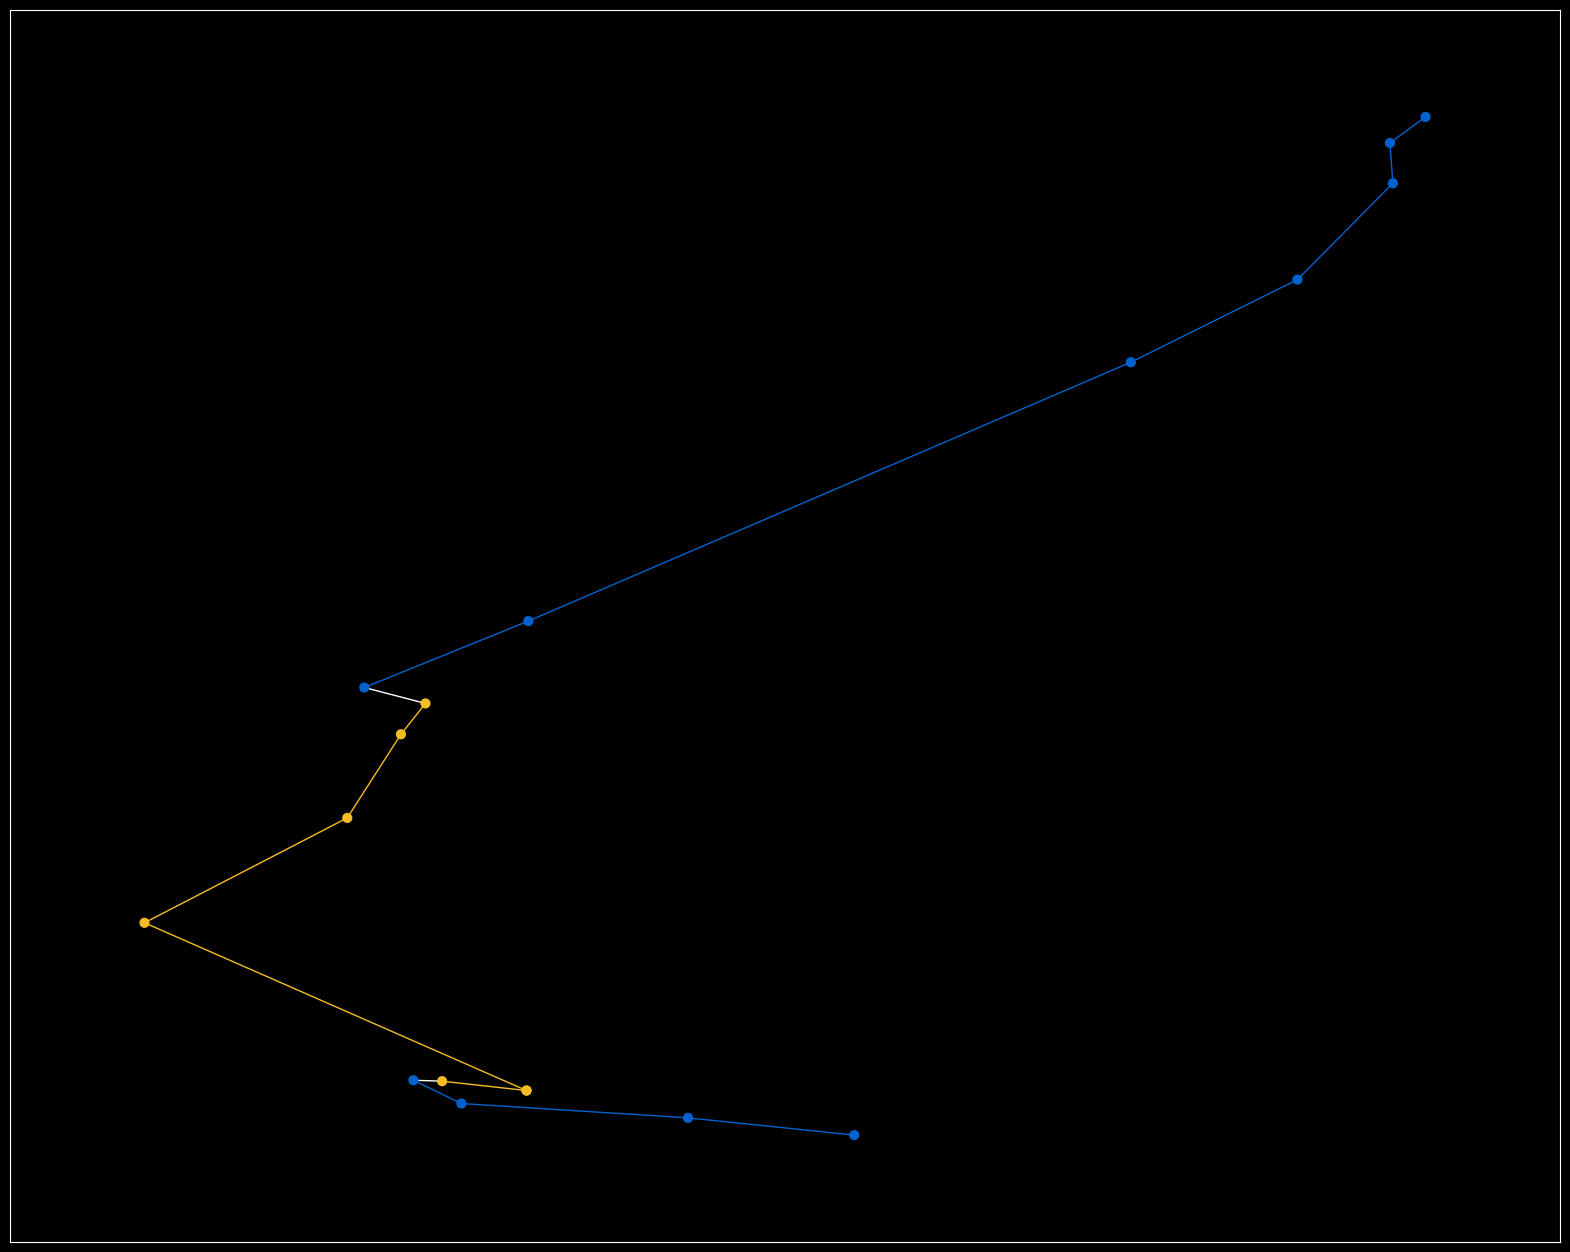

In [40]:
plt.figure(figsize=(20,16))
nx.draw_networkx_edges(gn,pos=posxy,arrows=False, node_size=40, nodelist=list(gn.nodes), edge_color=eclist)
nx.draw_networkx_nodes(gn, node_color=nodecolors, pos=posalldict, node_size=40, label=False, alpha = 1)
plt.show()